# Comparison figure — all three cases, one presentation slide

Combines the three sizing results (`BorefieldSizingLeuven_v1_case_a.ipynb`, `..._case_b.ipynb`, `..._case_c.ipynb` = the main `BorefieldSizingLeuven_v1.ipynb`) into a single figure with a shared map scale, so the size differences between scenarios are directly comparable at a glance.

**Note on reproducibility**: the borehole counts below are copied from those three notebooks' last executed output (each takes ~10-15 minutes to run due to the DOV/pydov queries and the sizing extrapolation, so this notebook doesn't re-run them). If any case is re-run with different assumptions, update the `CASES` dict below to match.


In [1]:
import pathlib

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

DATA_DIR = pathlib.Path(r"C:\Workdir\Develop\ghetool\UrbanLab")
SPACING = 6.0  # m, fixed spacing between boreholes (same in all three cases)

COLOR_PAGE = "#f9f9f7"
COLOR_SURFACE = "#fcfcfb"
COLOR_CITY_FILL = "#b7d3f6"
COLOR_CITY_EDGE = "#5f7ea8"
COLOR_FIELD_FILL = "#d03b3b"
COLOR_FIELD_EDGE = "#7a1f1f"
COLOR_TEXT_PRIMARY = "#0b0b0b"
COLOR_TEXT_SECONDARY = "#52514e"

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Segoe UI", "Arial", "DejaVu Sans"]

# Results copied from the last executed run of each sizing notebook - see the note above.
CASES = [
    {"label": "Case a", "subtitle": "All buildings", "side": 795},
    {"label": "Case b", "subtitle": "Residential only", "side": 434},
    {"label": "Case c", "subtitle": "All buildings, flat industry +\n15% summer cooling", "side": 760},
]


In [2]:
wfs_url = (
    "https://www.mercator.vlaanderen.be/raadpleegdienstenmercatorpubliek/wfs?service=WFS&version=2.0.0"
    "&request=GetFeature&typeNames=er:er_wrmtk_wvrg_statsec_2023&outputFormat=application/json"
)
gdf = gpd.read_file(wfs_url)
verbruik_leuven = gdf[gdf.statsec_code.str.startswith("24062A")]  # Leuven centrum, same scope as the sizing notebooks
leuven_area = verbruik_leuven.geometry.area.sum()
city_outline = verbruik_leuven.geometry.union_all()  # dissolve sub-sectors into one clean silhouette
centroid = city_outline.centroid

for c in CASES:
    c["number_of_boreholes"] = c["side"] * c["side"]
    c["footprint_area"] = ((c["side"] - 1) * SPACING) ** 2
    c["pct"] = c["footprint_area"] / leuven_area * 100

print(f"Leuven centrum area: {leuven_area / 1e4:.1f} ha ({leuven_area / 1e6:.2f} km^2)")
for c in CASES:
    print(f"{c['label']}: {c['number_of_boreholes']:,} boreholes, {c['footprint_area'] / 1e6:.2f} km^2, {c['pct']:.1f}% of Leuven centrum")


Leuven centrum area: 569.7 ha (5.70 km^2)
Case a: 632,025 boreholes, 22.70 km^2, 398.4% of Leuven centrum
Case b: 188,356 boreholes, 6.75 km^2, 118.5% of Leuven centrum
Case c: 577,600 boreholes, 20.74 km^2, 364.1% of Leuven centrum


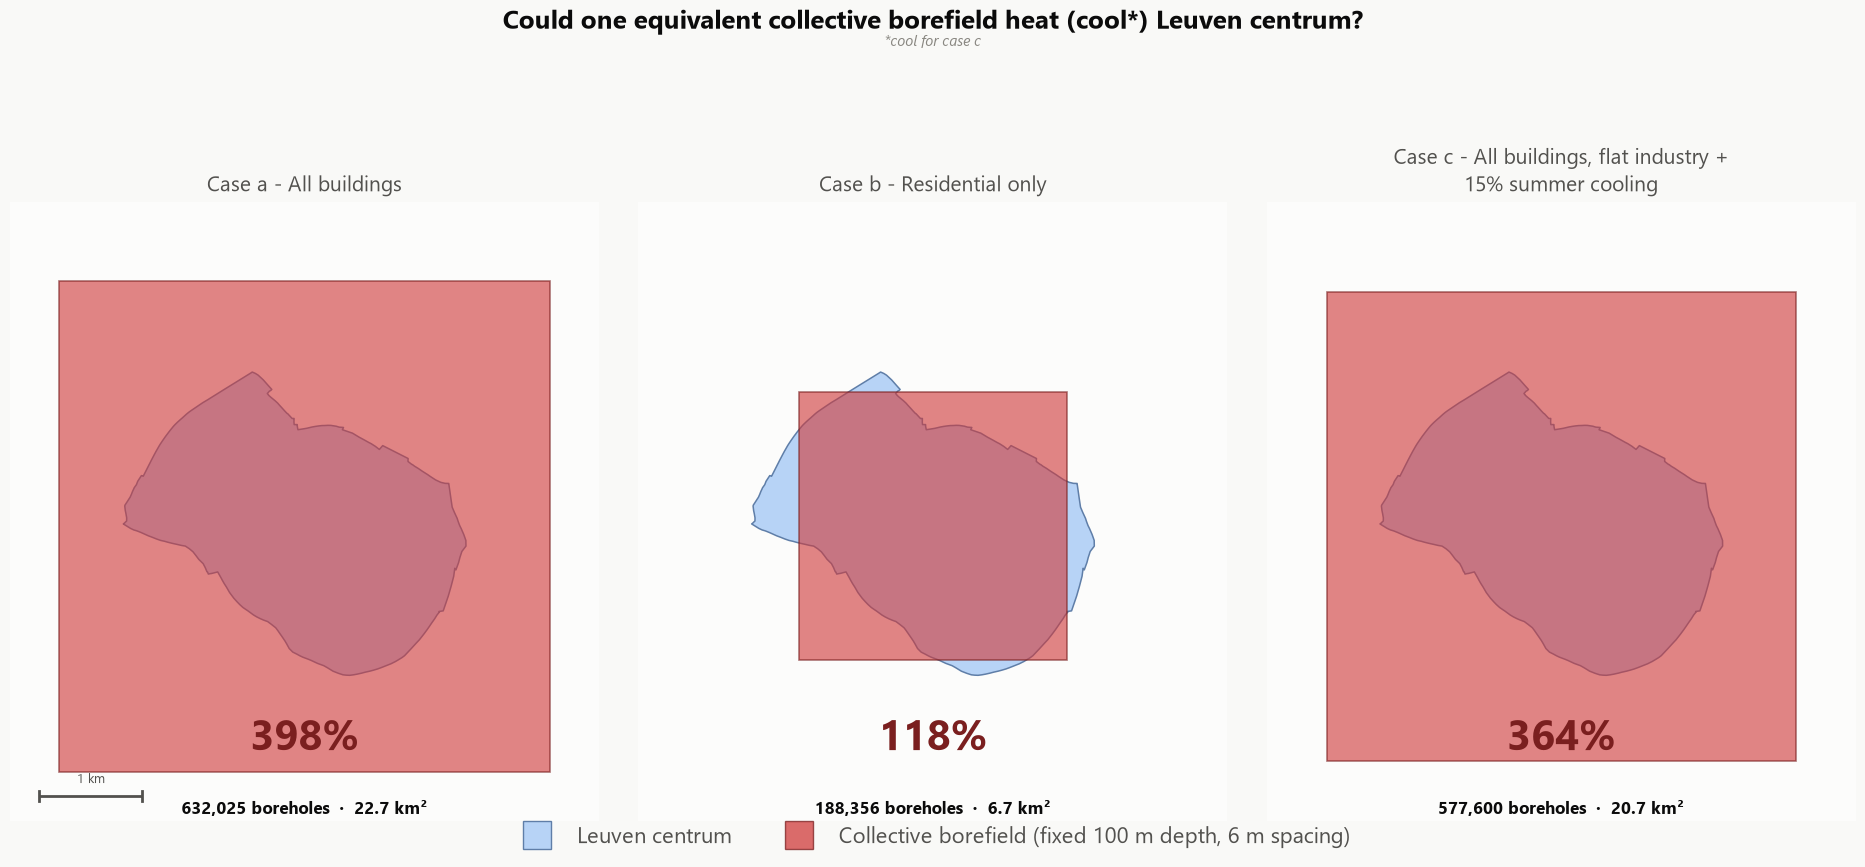

In [3]:
# Shared extent across all three panels (based on the largest field, case a), so the three scenarios are
# directly comparable at a glance - each panel is at the exact same map scale.
city_minx, city_miny, city_maxx, city_maxy = verbruik_leuven.total_bounds
max_width = max((c["side"] - 1) * SPACING for c in CASES)
field_minx, field_miny = centroid.x - max_width / 2, centroid.y - max_width / 2
field_maxx, field_maxy = centroid.x + max_width / 2, centroid.y + max_width / 2
minx, miny = min(city_minx, field_minx), min(city_miny, field_miny)
maxx, maxy = max(city_maxx, field_maxx), max(city_maxy, field_maxy)
pad = 0.10 * max(maxx - minx, maxy - miny)
xlim = (minx - pad, maxx + pad)
ylim = (miny - pad, maxy + 0.16 * (maxy - miny))

fig, axes = plt.subplots(1, 3, figsize=(19, 8.1), facecolor=COLOR_PAGE)

for ax, c in zip(axes, CASES):
    ax.set_facecolor(COLOR_SURFACE)
    gpd.GeoSeries([city_outline]).plot(ax=ax, color=COLOR_CITY_FILL, edgecolor=COLOR_CITY_EDGE, linewidth=1.1, zorder=2)
    width = height = (c["side"] - 1) * SPACING
    rect = Rectangle((centroid.x - width / 2, centroid.y - height / 2), width, height,
                      facecolor=COLOR_FIELD_FILL, edgecolor=COLOR_FIELD_EDGE, linewidth=1.2, alpha=0.62, zorder=3)
    ax.add_patch(rect)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(f"{c['label']} - {c['subtitle']}", fontsize=15, color=COLOR_TEXT_SECONDARY, linespacing=1.4, pad=8)
    ax.text(0.5, 0.10, f"{c['pct']:.0f}%", transform=ax.transAxes, ha="center", va="bottom",
            fontsize=30, fontweight="bold", color=COLOR_FIELD_EDGE, zorder=6)
    ax.text(0.5, 0.005, f"{c['number_of_boreholes']:,} boreholes  ·  {c['footprint_area'] / 1e6:.1f} km²",
            transform=ax.transAxes, ha="center", va="bottom", fontsize=12.5, color=COLOR_TEXT_PRIMARY,
            fontweight="bold", zorder=6)

# scale bar on the first panel only - the extent is shared across all three
ax0 = axes[0]
bar_len = 1000  # m
x0 = xlim[0] + 0.05 * (xlim[1] - xlim[0])
y0 = ylim[0] + 0.04 * (ylim[1] - ylim[0])
ax0.plot([x0, x0 + bar_len], [y0, y0], color=COLOR_TEXT_SECONDARY, linewidth=2, solid_capstyle="butt", zorder=5)
ax0.plot([x0, x0], [y0 - 45, y0 + 45], color=COLOR_TEXT_SECONDARY, linewidth=2, zorder=5)
ax0.plot([x0 + bar_len, x0 + bar_len], [y0 - 45, y0 + 45], color=COLOR_TEXT_SECONDARY, linewidth=2, zorder=5)
ax0.text(x0 + bar_len / 2, y0 + 100, "1 km", ha="center", va="bottom", fontsize=9, color=COLOR_TEXT_SECONDARY)

legend_handles = [
    Line2D([0], [0], marker='s', markersize=20, markerfacecolor=COLOR_CITY_FILL, markeredgecolor=COLOR_CITY_EDGE,
           linewidth=0, label="Leuven centrum"),
    Line2D([0], [0], marker='s', markersize=20, markerfacecolor=COLOR_FIELD_FILL, markeredgecolor=COLOR_FIELD_EDGE,
           linewidth=0, alpha=0.75, label="Collective borefield (fixed 100 m depth, 6 m spacing)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, frameon=False, fontsize=16,
           labelcolor=COLOR_TEXT_SECONDARY, bbox_to_anchor=(0.5, -0.01))

fig.suptitle("Could one equivalent collective borefield heat (cool*) Leuven centrum?", fontsize=19,
             fontweight="bold", color=COLOR_TEXT_PRIMARY, y=1.05)
fig.text(0.5, 1.005, "*cool for case c", fontsize=10.5, style="italic", color="#898781", ha="center")

fig.tight_layout(rect=[0, 0.03, 1, 0.88])
fig.savefig(DATA_DIR / "comparison_figure.png", dpi=150, facecolor=COLOR_PAGE, bbox_inches="tight")
plt.show()
